In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler 
from  scipy.stats import pearsonr
from scipy.stats import chi2_contingency
import seaborn as sn
import warnings 

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


# EDA

In [3]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [4]:
df.shape

(918, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [7]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

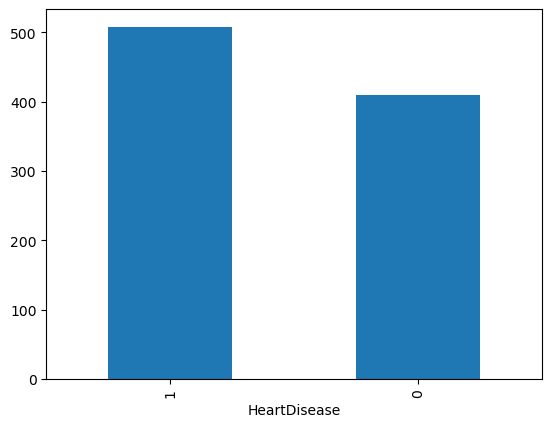

In [8]:
df['HeartDisease'].value_counts().plot(kind = 'bar')

In [9]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

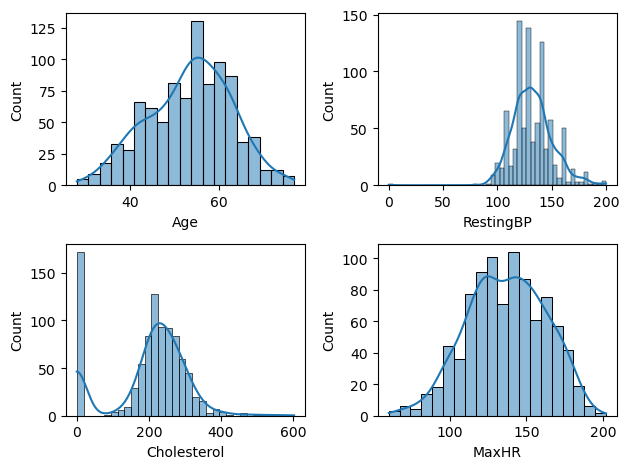

In [10]:
def ploting(var , num):
    plt.subplot(2,2 , num)
    sn.histplot(df[var] , kde = True)
ploting('Age' , 1)
ploting('RestingBP' , 2)
ploting('Cholesterol' , 3) 
ploting('MaxHR' , 4)

plt.tight_layout()

In [11]:
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
230      9
      ... 
392      1
316      1
153      1
466      1
131      1
Name: count, Length: 222, dtype: int64

In [12]:
ch_mean = df.loc[df['Cholesterol'] != 0 ,'Cholesterol'].mean()
ch_mean

np.float64(244.6353887399464)

In [13]:
df['Cholesterol'] = df['Cholesterol'].replace(0 , ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

In [14]:
resting_bp_mean = df.loc[df['RestingBP'] != 0 , 'RestingBP'].mean()
resting_bp_mean

np.float64(132.54089422028352)

In [15]:
df['RestingBP'] = df['RestingBP'].replace(0 , resting_bp_mean)
df['RestingBP'] = df['RestingBP'].round(2)

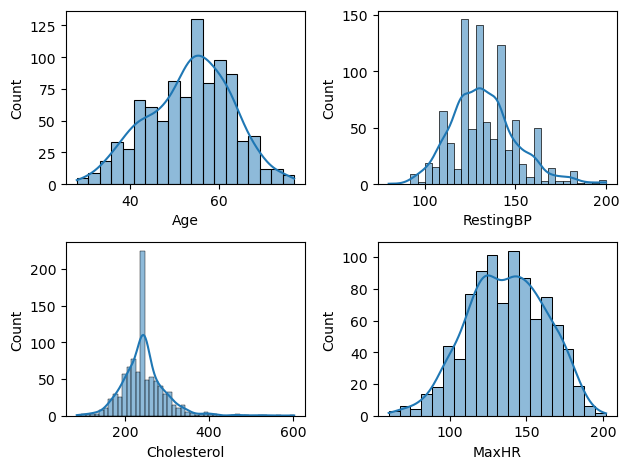

In [16]:
def ploting(var , num):
    plt.subplot(2,2 , num)
    sn.histplot(df[var] , kde = True)
ploting('Age' , 1)
ploting('RestingBP' , 2)
ploting('Cholesterol' , 3) 
ploting('MaxHR' , 4)

plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

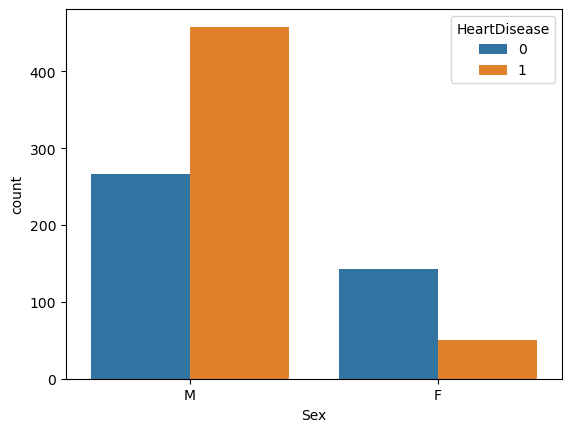

In [17]:
sn.countplot(x = df['Sex'] , hue = df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

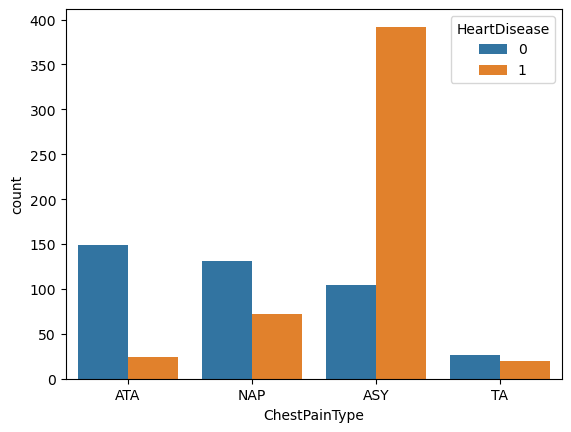

In [18]:
sn.countplot(x = df['ChestPainType'] , hue = df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

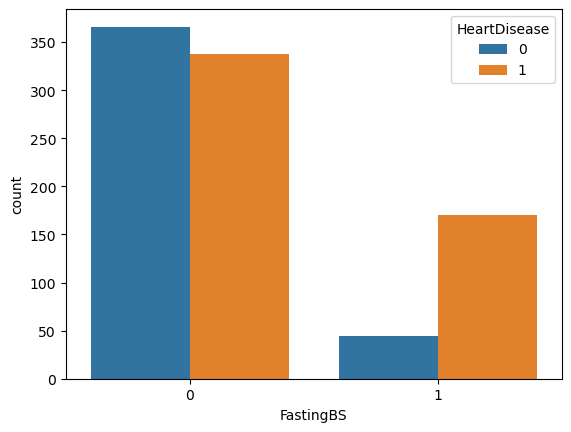

In [19]:
sn.countplot(x = df['FastingBS'] , hue = df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

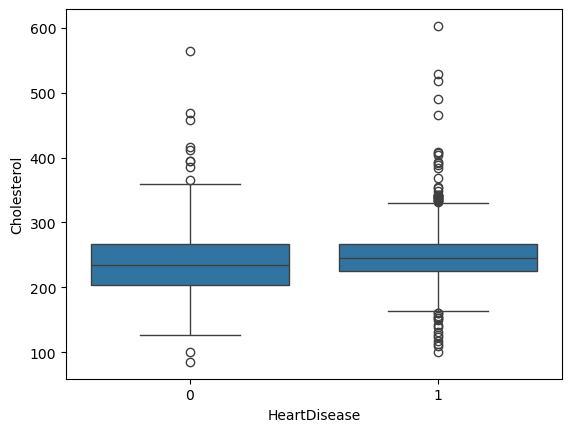

In [20]:
sn.boxplot(x='HeartDisease' , y  = df['Cholesterol'] , data = df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

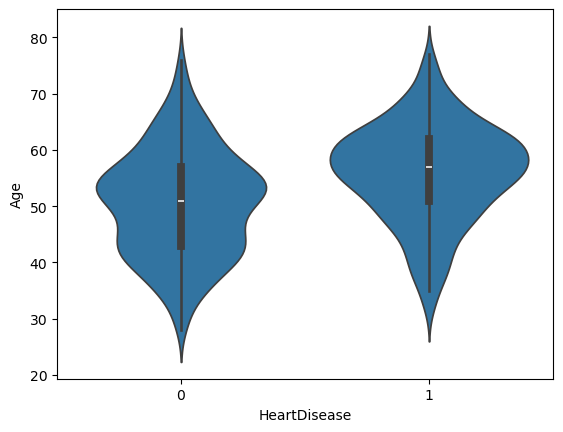

In [21]:
sn.violinplot(x = 'HeartDisease' , y = 'Age' , data  = df)

<Axes: >

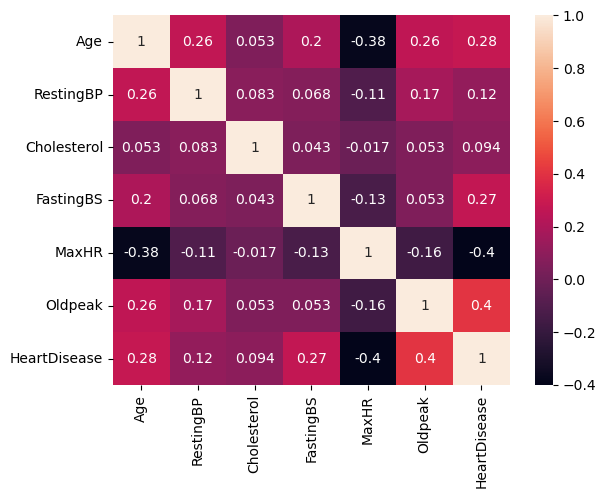

In [22]:
sn.heatmap(df.corr(numeric_only=True) , annot = True)

# Data Preprocessing  & Cleaning

In [23]:
df_encode= pd.get_dummies(df , drop_first=True).astype(int)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [24]:
# Standard - Scaler

# from sklearn.preprocessing import StandardScaler 

numerical_col = ['Age' , 'RestingBP' , 'Cholesterol' , 'MaxHR' , 'Oldpeak' ]
scaler = StandardScaler()
df_encode[numerical_col] = scaler.fit_transform(df_encode[numerical_col])
df_encode.head()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1


# Model creation

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score , f1_score , classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [30]:
X = df_encode.drop('HeartDisease' , axis = 1)
y = df_encode['HeartDisease']

In [34]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

In [36]:
# Feature Scaling -> Decision Tree , SVM , KNN 

scaler = StandardScaler()

X_train_scaled =scaler.fit_transform(X_train)
X_test_scaled =scaler.fit_transform(X_test)

In [49]:
models = {
    'Logistic Regression' : LogisticRegression(),
    'KNN'               : KNeighborsClassifier(),
    'Naive Bayes'       : GaussianNB(), 
    'Decision Tree'     : DecisionTreeClassifier(), 
    'SVM'               : SVC(probability=True),
}

In [50]:
results = []

In [51]:
for name , model in models.items():
    model.fit(X_train_scaled , y_train)
    y_pred   = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test , y_pred)
    f1       = f1_score(y_test , y_pred)

    results.append({
        'models' : name , 
        'accuracy' : round(accuracy ,4), 
        'F1 Score ' : round(f1,4)
    })

In [52]:
results

[{'models': 'Logistic Regression', 'accuracy': 0.8696, 'F1 Score ': 0.8857},
 {'models': 'KNN', 'accuracy': 0.8641, 'F1 Score ': 0.8815},
 {'models': 'Naive Bayes', 'accuracy': 0.8533, 'F1 Score ': 0.8683},
 {'models': 'Decision Tree', 'accuracy': 0.7717, 'F1 Score ': 0.7961},
 {'models': 'SVM', 'accuracy': 0.8478, 'F1 Score ': 0.8679}]

                models  accuracy  F1 Score 
0  Logistic Regression    0.8696     0.8857
1                  KNN    0.8641     0.8815
2          Naive Bayes    0.8533     0.8683
3        Decision Tree    0.7609     0.7864
4                  SVM    0.8478     0.8679


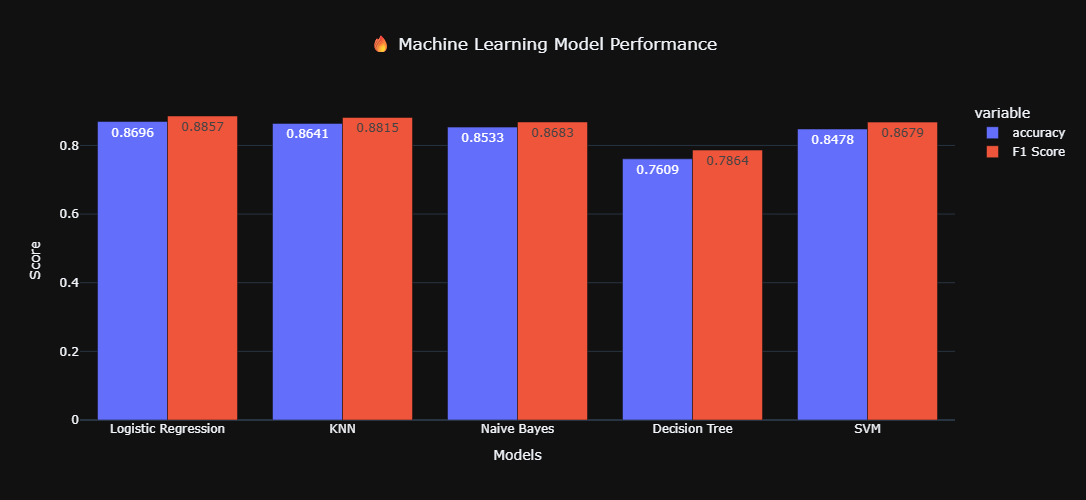

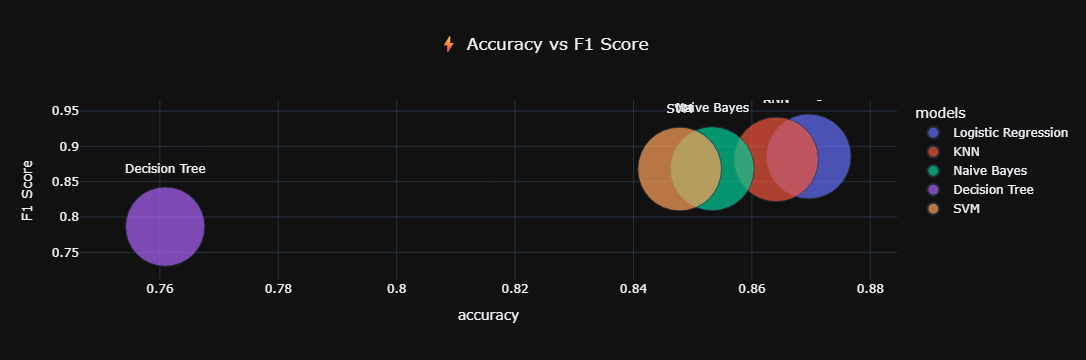

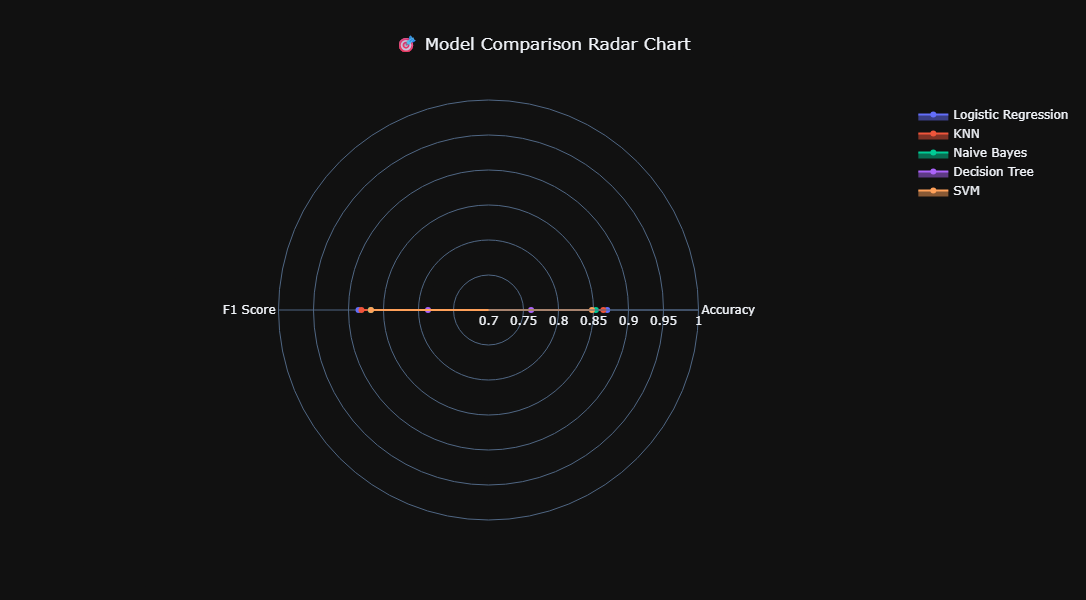

In [53]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

results = [
    {'models': 'Logistic Regression', 'accuracy': 0.8696, 'F1 Score ': 0.8857},
    {'models': 'KNN', 'accuracy': 0.8641, 'F1 Score ': 0.8815},
    {'models': 'Naive Bayes', 'accuracy': 0.8533, 'F1 Score ': 0.8683},
    {'models': 'Decision Tree', 'accuracy': 0.7609, 'F1 Score ': 0.7864},
    {'models': 'SVM', 'accuracy': 0.8478, 'F1 Score ': 0.8679}
]
df = pd.DataFrame(results)

print(df)


# 1. COOL INTERACTIVE GROUPED BAR CHART


fig = px.bar(
    df,
    x='models',
    y=['accuracy', 'F1 Score '],
    barmode='group',
    text_auto='.4f',
    title='🔥 Machine Learning Model Performance',
    height=500
)
fig.update_layout(
    template='plotly_dark',
    xaxis_title='Models',
    yaxis_title='Score',
    title_x=0.5
)
fig.show()


# 2. BUBBLE / SCATTER VISUALIZATION

fig2 = px.scatter(
    df,
    x='accuracy',
    y='F1 Score ',
    size='accuracy',
    color='models',
    hover_name='models',
    text='models',
    title='⚡ Accuracy vs F1 Score',
    size_max=60
)
fig2.update_traces(textposition='top center')
fig2.update_layout(
    template='plotly_dark',
    title_x=0.5
)
fig2.show()



# 3. RADAR CHART (VERY COOL)

fig3 = go.Figure()

for i in range(len(df)):
    fig3.add_trace(go.Scatterpolar(
        r=[
            df.loc[i, 'accuracy'],
            df.loc[i, 'F1 Score ']
        ],
        theta=['Accuracy', 'F1 Score'],
        fill='toself',
        name=df.loc[i, 'models']
    ))

fig3.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0.7, 1]
        )
    ),
    template='plotly_dark',
    title='🎯 Model Comparison Radar Chart',
    title_x=0.5,
    height=600
)

fig3.show()

---

In [54]:
import joblib

joblib.dump(models['KNN'] , 'KNN_Heart_Prediction.pkl')
joblib.dump(scaler , 'scaler.pkl')
joblib.dump(X.columns.to_list(), 'columns.pkl')

['columns.pkl']